In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

In [2]:
df = pd.read_csv("data/flight_del_jan_to_dec_25.csv")
print("Shape:", df.shape)
df.head()

Shape: (7001619, 11)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DEP_DEL15,CANCELLED,DIVERTED,DISTANCE
0,1,1,3,AA,ABQ,DFW,500,0.0,0.0,0.0,569.0
1,1,1,3,AA,ABQ,DFW,555,0.0,0.0,0.0,569.0
2,1,1,3,AA,ABQ,DFW,820,0.0,0.0,0.0,569.0
3,1,1,3,AA,ABQ,DFW,1032,0.0,0.0,0.0,569.0
4,1,1,3,AA,ABQ,DFW,1700,0.0,0.0,0.0,569.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7001619 entries, 0 to 7001618
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   MONTH              int64  
 1   DAY_OF_MONTH       int64  
 2   DAY_OF_WEEK        int64  
 3   OP_UNIQUE_CARRIER  str    
 4   ORIGIN             str    
 5   DEST               str    
 6   CRS_DEP_TIME       int64  
 7   DEP_DEL15          float64
 8   CANCELLED          float64
 9   DIVERTED           float64
 10  DISTANCE           float64
dtypes: float64(4), int64(4), str(3)
memory usage: 587.6 MB


In [4]:
df.isna().sum()

MONTH                    0
DAY_OF_MONTH             0
DAY_OF_WEEK              0
OP_UNIQUE_CARRIER        0
ORIGIN                   0
DEST                     0
CRS_DEP_TIME             0
DEP_DEL15            98591
CANCELLED                0
DIVERTED                 0
DISTANCE                 0
dtype: int64

In [5]:
df[df["DEP_DEL15"].isna()]["MONTH"].value_counts().sort_index()

MONTH
1     15923
2      7139
3      6609
4      4667
5      5987
6      9202
7     14549
8      6147
9      2721
10     3064
11    13937
12     8646
Name: count, dtype: int64

In [6]:
df["MONTH"].value_counts().sort_index()

MONTH
1     539747
2     504884
3     600872
4     583950
5     605648
6     611575
7     631428
8     602378
9     562439
10    605844
11    570550
12    582304
Name: count, dtype: int64

In [7]:
print("Cancelled flights:", int(df["CANCELLED"].sum()))
print("Diverted flights:", int(df["DIVERTED"].sum()))

Cancelled flights: 102876
Diverted flights: 19258


In [8]:
# cancelled and diverted flights inherently cannot be delayed so removing them
df = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()

In [9]:
df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DEP_DEL15,CANCELLED,DIVERTED,DISTANCE
0,1,1,3,AA,ABQ,DFW,500,0.0,0.0,0.0,569.0
1,1,1,3,AA,ABQ,DFW,555,0.0,0.0,0.0,569.0
2,1,1,3,AA,ABQ,DFW,820,0.0,0.0,0.0,569.0
3,1,1,3,AA,ABQ,DFW,1032,0.0,0.0,0.0,569.0
4,1,1,3,AA,ABQ,DFW,1700,0.0,0.0,0.0,569.0


In [10]:
# removing missing values for delays
df = df.dropna(subset=["DEP_DEL15"])
df.isna().sum()

MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
ORIGIN               0
DEST                 0
CRS_DEP_TIME         0
DEP_DEL15            0
CANCELLED            0
DIVERTED             0
DISTANCE             0
dtype: int64

In [11]:
df["DEP_DEL15"]    = df["DEP_DEL15"].astype(int)
df["MONTH"]        = df["MONTH"].astype(int)
df["DAY_OF_MONTH"] = df["DAY_OF_MONTH"].astype(int)
df["DAY_OF_WEEK"]  = df["DAY_OF_WEEK"].astype(int)
df["DISTANCE"]     = df["DISTANCE"].astype(float)

In [12]:
dep_hour_check = (df["CRS_DEP_TIME"] // 100).astype(int)
print(dep_hour_check[~dep_hour_check.between(0, 23)].value_counts())
print(f"Count of bad rows: {(~dep_hour_check.between(0, 23)).sum()}")

CRS_DEP_TIME
24    1
Name: count, dtype: int64
Count of bad rows: 1


In [13]:
# there is only one row where time is in form 24xx instead of 00xx, so dropping it
df = df[df["CRS_DEP_TIME"] != 2400].copy()

# deriving dep_hour 
df["DEP_HOUR"] = (df["CRS_DEP_TIME"] // 100).astype(int)
assert df["DEP_HOUR"].between(0, 23).all(), "Unexpected dep_hour values"
print("DEP_HOUR OK, range:", df["DEP_HOUR"].min(), "to", df["DEP_HOUR"].max())

DEP_HOUR OK, range: 0 to 23


In [14]:
# dropping columns no longer needed
df = df.drop(columns=["CANCELLED", "DIVERTED", "CRS_DEP_TIME"])

print("\nShape after cleaning:", df.shape)


Shape after cleaning: (6879484, 9)


In [15]:
print("Class Balance")
print(f"Total flights:   {len(df):,}")
print(f"Delayed (1):     {df['DEP_DEL15'].sum():,} ({df['DEP_DEL15'].mean():.1%})")
print(f"On time (0):     {(df['DEP_DEL15']==0).sum():,} ({1-df['DEP_DEL15'].mean():.1%})")
print(f"Unique carriers: {df['OP_UNIQUE_CARRIER'].nunique()}")
print(f"Unique origins:  {df['ORIGIN'].nunique()}")
print(f"Months present:  {sorted(df['MONTH'].unique())}")

Class Balance
Total flights:   6,879,484
Delayed (1):     1,492,441 (21.7%)
On time (0):     5,387,043 (78.3%)
Unique carriers: 14
Unique origins:  352
Months present:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## EDA

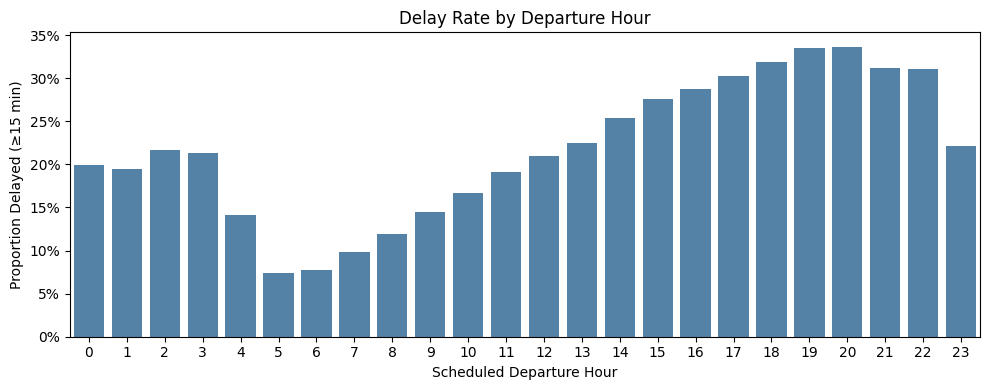

In [16]:
hourly = df.groupby("DEP_HOUR")["DEP_DEL15"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=hourly.index, y=hourly.values, color="steelblue", ax=ax)
ax.set_title("Delay Rate by Departure Hour")
ax.set_xlabel("Scheduled Departure Hour")
ax.set_ylabel("Proportion Delayed (≥15 min)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_hour.png", dpi=150)
plt.show()


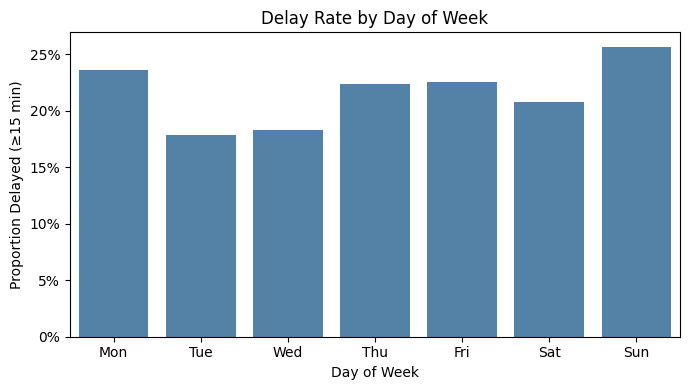

In [17]:
day_labels = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
daily = df.groupby("DAY_OF_WEEK")["DEP_DEL15"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=[day_labels[d] for d in daily.index], y=daily.values,
            color="steelblue", ax=ax)
ax.set_title("Delay Rate by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Proportion Delayed (≥15 min)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_dow.png", dpi=150)
plt.show()

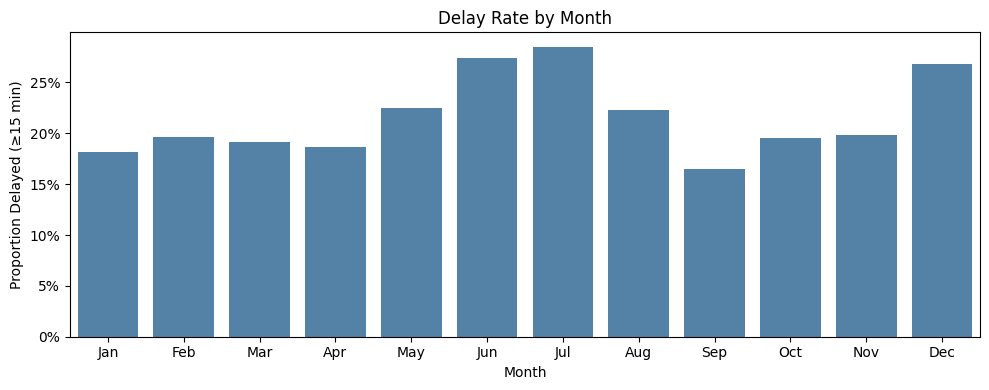

In [18]:
month_labels = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly = df.groupby("MONTH")["DEP_DEL15"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=[month_labels[m] for m in monthly.index], y=monthly.values,
            color="steelblue", ax=ax)
ax.set_title("Delay Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Proportion Delayed (≥15 min)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_month.png", dpi=150)
plt.show()

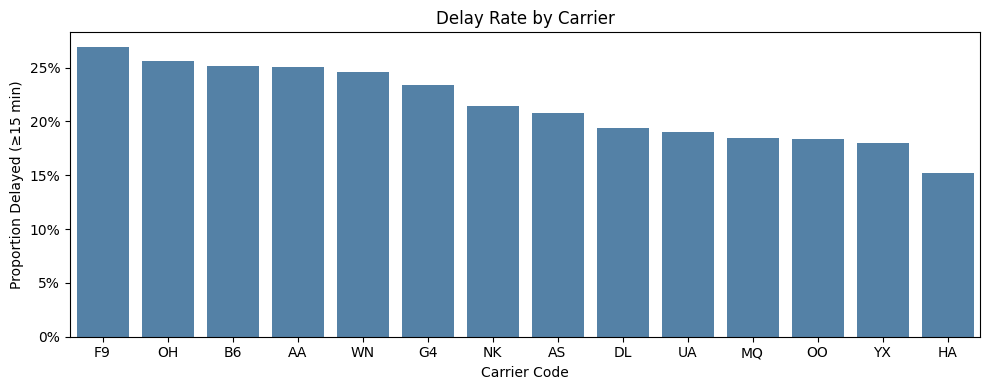

In [19]:
carrier = (df.groupby("OP_UNIQUE_CARRIER")
             .agg(total=("DEP_DEL15","count"), delay_rate=("DEP_DEL15","mean"))
             .sort_values("delay_rate", ascending=False)
             .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=carrier, x="OP_UNIQUE_CARRIER", y="delay_rate",
            color="steelblue", ax=ax)
ax.set_title("Delay Rate by Carrier")
ax.set_xlabel("Carrier Code")
ax.set_ylabel("Proportion Delayed (≥15 min)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_carrier.png", dpi=150)
plt.show()

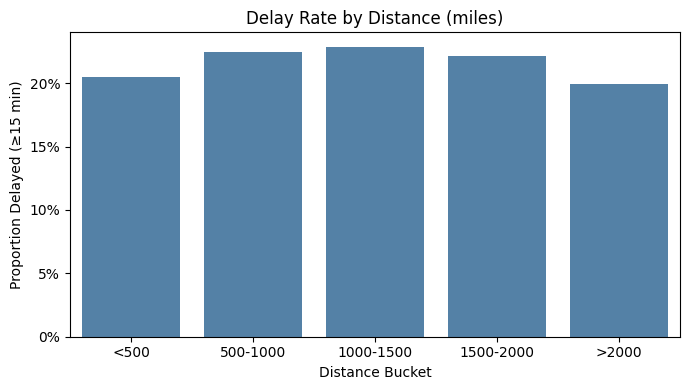

In [20]:
df["distance_bucket"] = pd.cut(df["DISTANCE"],
                                bins=[0, 500, 1000, 1500, 2000, 5000],
                                labels=["<500","500-1000","1000-1500",
                                        "1500-2000",">2000"])
dist = df.groupby("distance_bucket", observed=True)["DEP_DEL15"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=dist.index, y=dist.values, color="steelblue", ax=ax)
ax.set_title("Delay Rate by Distance (miles)")
ax.set_xlabel("Distance Bucket")
ax.set_ylabel("Proportion Delayed (≥15 min)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_distance.png", dpi=150)
plt.show()

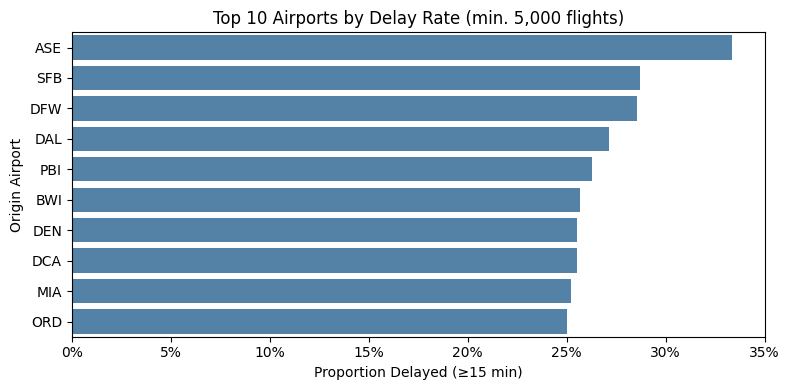

In [21]:
airport = (df.groupby("ORIGIN")
             .agg(total=("DEP_DEL15","count"), delay_rate=("DEP_DEL15","mean"))
             .query("total >= 5000")
             .nlargest(10, "delay_rate")
             .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=airport, x="delay_rate", y="ORIGIN", color="steelblue", ax=ax)
ax.set_title("Top 10 Airports by Delay Rate (min. 5,000 flights)")
ax.set_xlabel("Proportion Delayed (≥15 min)")
ax.set_ylabel("Origin Airport")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("results/delay_by_airport.png", dpi=150)
plt.show()

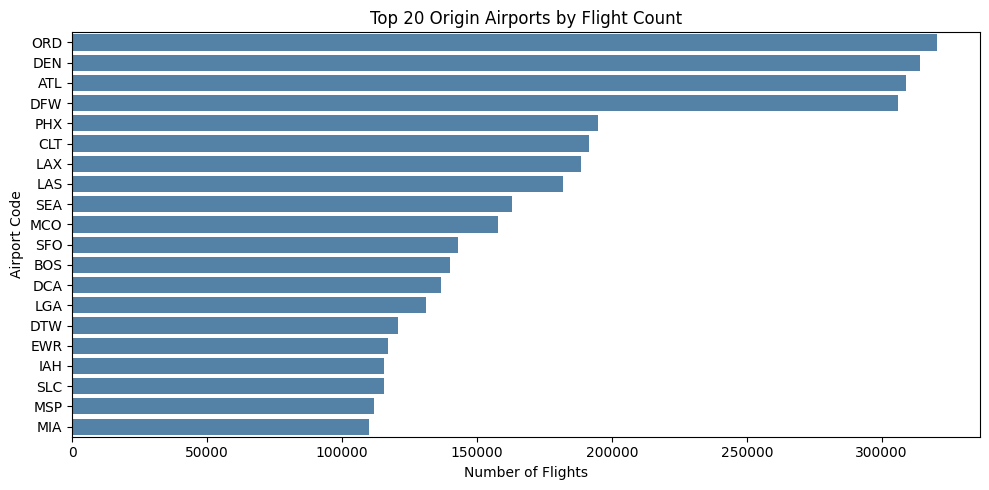

In [22]:
# Top 20 origin airports by flight count
fig, ax = plt.subplots(figsize=(10, 5))
origin_counts = df["ORIGIN"].value_counts().head(20)
sns.barplot(x=origin_counts.values, y=origin_counts.index, color="steelblue", ax=ax)
ax.set_title("Top 20 Origin Airports by Flight Count")
ax.set_xlabel("Number of Flights")
ax.set_ylabel("Airport Code")
plt.tight_layout()
plt.savefig("results/top_origins.png", dpi=150)
plt.show()

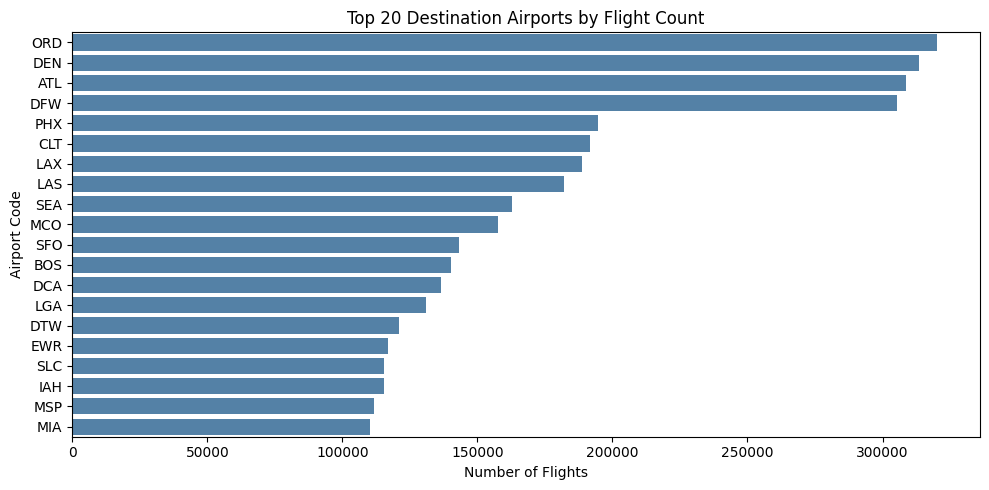

In [23]:
# Top 20 destination airports by flight count
fig, ax = plt.subplots(figsize=(10, 5))
dest_counts = df["DEST"].value_counts().head(20)
sns.barplot(x=dest_counts.values, y=dest_counts.index, color="steelblue", ax=ax)
ax.set_title("Top 20 Destination Airports by Flight Count")
ax.set_xlabel("Number of Flights")
ax.set_ylabel("Airport Code")
plt.tight_layout()
plt.savefig("results/top_destinations.png", dpi=150)
plt.show()

In [24]:
df.columns

Index(['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN',
       'DEST', 'DEP_DEL15', 'DISTANCE', 'DEP_HOUR', 'distance_bucket'],
      dtype='str')

In [25]:
df = df.drop(columns=["distance_bucket"])

The full dataset contains ~6.9M flights. Training both models on the full dataset is computationally expensive, particularly for the Bayesian model. hence we are taking a 600k stratified sample for the MLP, and will further subsample to 50k for the Bayesian model.We stratify by MONTH x DEP_DEL15 jointly to ensure:
(1) all 12 months are represented proportionally (preserves seasonality)
(2) the 78/22 class ratio is preserved (avoids bias toward on-time flights)

train_test_split with stratify is used as it is the standard approach for stratified sampling, it guarantees proportional representation across all strata without manual group iteration.

In [26]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 600_000

_, sample_df = train_test_split(
    df,
    test_size=SAMPLE_SIZE / len(df),
    random_state=42,
    stratify=df[["MONTH", "DEP_DEL15"]]
)

sample_df = sample_df.reset_index(drop=True)

print(f"Sample size:      {len(sample_df):,}")
print(f"Delay rate:       {sample_df['DEP_DEL15'].mean():.2%}")
print(f"\nFlights per month:")
print(
    sample_df.groupby("MONTH")["DEP_DEL15"]
    .agg(["count", "mean"])
    .rename(columns={"count": "flights", "mean": "delay_rate"})
    .to_string()
)

Sample size:      600,000
Delay rate:       21.69%

Flights per month:
       flights  delay_rate
MONTH                     
1        45550    0.182020
2        43301    0.195954
3        51658    0.191122
4        50387    0.186794
5        52118    0.224529
6        52283    0.273875
7        53447    0.285030
8        51783    0.223027
9        48695    0.164719
10       52466    0.195727
11       48431    0.198695
12       49881    0.268379


In [27]:
# verifying carrier and airport distributions are preserved
carrier_check = pd.DataFrame({
    "full": df["OP_UNIQUE_CARRIER"].value_counts(normalize=True).round(3),
    "sample": sample_df["OP_UNIQUE_CARRIER"].value_counts(normalize=True).round(3)
})
carrier_check["diff"] = (carrier_check["full"] - carrier_check["sample"]).abs()
print("Carrier distribution:")
print(carrier_check.to_string())

print("\nTop 20 origin distribution:")
airport_check = pd.DataFrame({
    "full": df["ORIGIN"].value_counts(normalize=True).head(20).round(3),
    "sample": sample_df["ORIGIN"].value_counts(normalize=True).head(20).round(3)
})
airport_check["diff"] = (airport_check["full"] - airport_check["sample"]).abs()
print(airport_check.to_string())

Carrier distribution:
                    full  sample   diff
OP_UNIQUE_CARRIER                      
WN                 0.200   0.199  0.001
DL                 0.147   0.148  0.001
AA                 0.139   0.139  0.000
OO                 0.120   0.120  0.000
UA                 0.114   0.114  0.000
YX                 0.049   0.048  0.001
MQ                 0.042   0.042  0.000
AS                 0.035   0.035  0.000
OH                 0.034   0.034  0.000
B6                 0.033   0.033  0.000
F9                 0.028   0.028  0.000
NK                 0.028   0.028  0.000
G4                 0.019   0.019  0.000
HA                 0.012   0.012  0.000

Top 20 origin distribution:
         full  sample   diff
ORIGIN                      
ATL     0.045   0.045  0.000
BOS     0.020   0.020  0.000
CLT     0.028   0.027  0.001
DCA     0.020   0.020  0.000
DEN     0.046   0.046  0.000
DFW     0.045   0.044  0.001
DTW     0.018   0.018  0.000
EWR     0.017   0.017  0.000
IAH     0.017   0.0

In [28]:
print(f"Unique origin airports:      {sample_df['ORIGIN'].nunique()}")
print(f"Unique destination airports: {sample_df['DEST'].nunique()}")

# cumulative flight coverage by top n airports
origin_counts = sample_df["ORIGIN"].value_counts(normalize=True).cumsum()
for n in [10, 20, 30, 50, 75, 100]:
    print(f"Top {n:3d} origins cover: {origin_counts.iloc[n-1]:.1%} of flights")

Unique origin airports:      350
Unique destination airports: 350
Top  10 origins cover: 33.8% of flights
Top  20 origins cover: 51.8% of flights
Top  30 origins cover: 64.7% of flights
Top  50 origins cover: 78.4% of flights
Top  75 origins cover: 86.6% of flights
Top 100 origins cover: 91.4% of flights


In [29]:
#sample_df.to_csv("data/sample_600k.csv", index=False)

## Preprocessing

In [30]:
X = sample_df.drop(columns=["DEP_DEL15"])
y = sample_df["DEP_DEL15"].astype(int)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train delay rate: {y_train.mean():.2%}")
print(f"Test  delay rate: {y_test.mean():.2%}")


Train: 480,000 rows | Test: 120,000 rows
Train delay rate: 21.69%
Test  delay rate: 21.69%


### Top-N Encoding
ORIGIN and DEST each have 350 unique airports. One-hot encoding all of them would add 700 sparse columns, most of which represent airports with very few flights and no meaningful signal. We keep the top 50 airports (covering 78.4% of flights) and group the rest as "Other". Crucially, the top-N cutoff is determined from the TRAINING set only. Applying it to the test set based on train frequencies prevents leakage, the model never sees test set information during any preprocessing step.This mirrors the same principle as fitting scalers on train only.

All 14 carriers are encoded without grouping since there are few enough that every carrier has sufficient representation in the training data.


In [32]:
def top_n_encode(train, test, col, n):
    """Keep top-N categories by train frequency, replace rest with 'Other'."""
    top = train[col].value_counts().nlargest(n).index
    train = train.copy()
    test  = test.copy()
    train[col] = train[col].where(train[col].isin(top), other="Other")
    test[col]  = test[col].where(test[col].isin(top),  other="Other")
    return train, test

X_train, X_test = top_n_encode(X_train, X_test, "ORIGIN", 50)
X_train, X_test = top_n_encode(X_train, X_test, "DEST",   50)
print(f"Unique ORIGIN values in train: {X_train['ORIGIN'].nunique()}")
print(f"Unique DEST values in train:   {X_train['DEST'].nunique()}")

Unique ORIGIN values in train: 51
Unique DEST values in train:   51


### One hot encoding

One hot encoding ORIGIN, DEST, OP_UNIQUE_CARRIER, MONTH, and DAY_OF_WEEK.

- ORIGIN/DEST/CARRIER: clearly categorical with no meaningful numeric ordering.

- MONTH: EDA showed a non-linear relationship with delay rate. June/July spike to ~27%, September drops to ~16%. Encoding as a scaled integer would falsely imply a monotonic relationship (eg month 12 > month 6).

- DAY_OF_WEEK: EDA showed Monday and Sunday have highest delay rates (~24%), Tuesday/Wednesday lowest (~18%). Again, no meaningful linear ordering 1→7.

In [33]:
cat_cols = ["ORIGIN", "DEST", "OP_UNIQUE_CARRIER", "MONTH", "DAY_OF_WEEK"]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True, dtype=int)

# align columns ensure test has the same columns as train, for edge case where a rare category appears in train but 
# not test (or vice versa), filling any missing columns with 0
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Feature count after encoding: {X_train.shape[1]}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Feature count after encoding: 133
Train shape: (480000, 133)
Test shape:  (120000, 133)


### Scaling

Applying StandardScaler to numeric columns. StandardScaler transforms each numeric feature to have mean=0 and std=1. This is preferred over MinMaxScaler for neural networks because it handles outliers better and is more appropriate when features follow roughly normal distributions. The scaler is fit on the training set only, then applied to both train and test. Fitting on the full dataset would leak test set statistics (mean, std) into the training process. Not using MinMaxScalar as range is from approx 30 miles to approx 5000 miles. MinMaxScaler could be distorted by those extremes. StandardScaler handles this relatively more cleanly.

- DAY_OF_MONTH: kept as a scaled numeric since one-hot encoding 31 values adds. excessive columns for marginal gain. The signal is weaker than month/day-of-week and a scaled integer is a reasonable estimation.

- DEP_HOUR: has a clear monotonic relationship with delay rate (delays accumulate through the day). A scaled numeric captures this well without needing 24 dummy columns.

- DISTANCE: continous numeric feature to be scaled


In [34]:
from sklearn.preprocessing import StandardScaler

num_cols = ["DAY_OF_MONTH", "DEP_HOUR", "DISTANCE"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

## MLP
Constructing a Multilayer Perceptron (MLP) with two hidden layers of width 64 and 32, and a single output node. The network computes:

    h⁽¹⁾ = ⟨W⁽¹⁾ᵀ x⟩₊         (width 64, ReLU activation)
    h⁽²⁾ = ⟨W⁽²⁾ᵀ h⁽¹⁾⟩₊      (width 32, ReLU activation)
    f(x) = σ(W⁽³⁾ᵀ h⁽²⁾)       (sigmoid output)

ReLU is used as the activation function for the hidden layers. The sigmoid activation on the output layer maps the pre-activation value to a probability in [0,1], appropriate for binary classification. Dropout (rate=0.3) is applied after each hidden layer to prevent overfitting by randomly zeroing a proportion of weights during each epoch of training.

The network is compiled with the Adam optimizer (https://keras.io/api/optimizers/adam/), an adaptive gradient descent method, and binary cross-entropy as the objective (loss) function.

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, classification_report

2026-04-14 16:13:16.954709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [36]:
n_features = X_train.shape[1]

inpx    = Input(shape=(n_features,))
hidden1 = Dense(64, activation="relu")(inpx)
drop1   = Dropout(0.3)(hidden1)
hidden2 = Dense(32, activation="relu")(drop1)
drop2   = Dropout(0.3)(hidden2)
out     = Dense(1, activation="sigmoid")(drop2)

model = Model(inputs=inpx, outputs=out)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=binary_crossentropy,
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 133)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

The dataset is imbalanced, approximately 78% of flights are on time and 22% are delayed. Without correction, a model can achieve 78% accuracy by predicting "on time" for every flight, learning nothing meaningful about delays. We address this by assigning a higher penalty for misclassifying delayed flights using class weights. The weights are computed using the standard balanced formula: each class weight is inversely proportional to its frequency in the training set. Given that the split is 78/22, we deem the dataset to be moderately imbalanced, and hence are not using more sever approaches such as SMOTE. 

During training, every time the model incorrectly predicts "on time" for a flight that was actually delayed, it receives a much larger gradient update than when it incorrectly predicts "delayed" for an on-time flight. This forces the model to pay more attention to the minority class rather than defaulting to always predicting the majority.

In [37]:
n_total   = len(y_train)
n_delayed = y_train.sum()
n_ontime  = n_total - n_delayed

weight_0 = n_total / (2 * n_ontime)
weight_1 = n_total / (2 * n_delayed)

class_weight = {0: weight_0, 1: weight_1}
print(f"Class weights: on-time={weight_0:.3f}, delayed={weight_1:.3f}")

Class weights: on-time=0.639, delayed=2.305


The weights W⁽¹⁾, W⁽²⁾, W⁽³⁾ are found by minimizing the binary cross-entropy objective function using gradient descent. The model is trained for 50 epochs with a batch size of 128. Each epoch performs a full pass over the training data in mini-batches of 128 observations, resulting in approximately 3,750 weight updates per epoch and 187,500 total updates across all epochs. A smaller batch size means each gradient estimate is noisier but the model updates more frequently, which
can help escape local minima and find better solutions. A validation split of 10% is held out from the training data to monitor the objective function on unseen data during training. If validation loss begins to rise while training loss continues to fall, the model is overfitting. The class weights computed above are passed to the training loop to correct for class imbalance.

In [38]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6219 - loss: 0.6449 - val_accuracy: 0.6565 - val_loss: 0.6264
Epoch 2/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6419 - loss: 0.6361 - val_accuracy: 0.6388 - val_loss: 0.6370
Epoch 3/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6485 - loss: 0.6327 - val_accuracy: 0.6450 - val_loss: 0.6354
Epoch 4/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6543 - loss: 0.6298 - val_accuracy: 0.6597 - val_loss: 0.6201
Epoch 5/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6580 - loss: 0.6278 - val_accuracy: 0.6621 - val_loss: 0.6183
Epoch 6/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6588 - loss: 0.6262 - val_accuracy: 0.6626 - val_loss: 0.6204
Epoch 7/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6613 - loss: 0.6251 - val_accuracy: 0.6640 - val_loss: 0.6240
Epoch 8/50
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6619 - loss: 0.6237 -

PLotting the objective function on the training and validation sets across epochs. A well-behaved training run shows both curves declining and converging. A widening gap between the two curves indicates the model has begun to overfit, memorizing the training data rather than learning generalizable patterns. Dropout helps mitigate this by randomly zeroing
weights during each epoch.

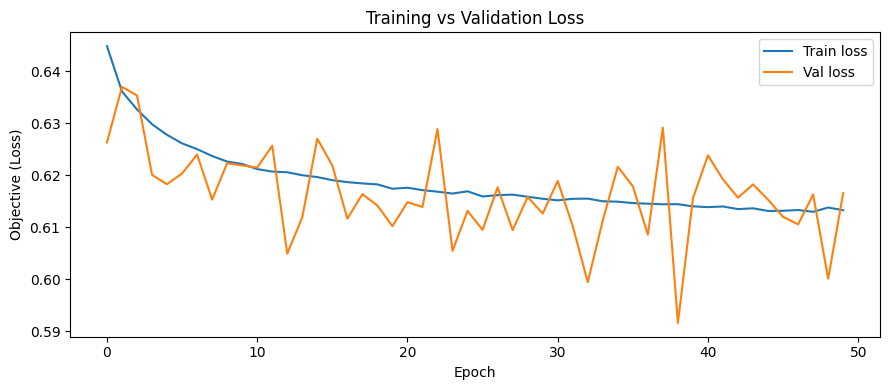

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history["loss"],     label="Train loss")
ax.plot(history.history["val_loss"], label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Objective (Loss)")
ax.set_title("Training vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("results/mlp_loss.png", dpi=150)
plt.show()

The training objective (loss) decreases steadily across all 50 epochs, indicating that gradient descent is successfully minimizing the binary cross-entropy objective function with each weight update. The model is trained with a batch size of 128, which produces a noisier gradient estimate per update compared to larger batches which explains the high variability in the
validation loss curve. Despite this noise, the validation loss follows a clear downward trend overall and never consistently rises above the training loss, indicating that the model is not overfitting. The dropout regularization applied after each hidden layer is effectively preventing the weights from over-specializing to the training data. The train loss curve begins to flatten after approximately epoch 30, suggesting the model is approaching convergence with the current architecture and feature set.

The model is evaluated on the held-out test set. Accuracy alone is not a reliable metric for imbalanced data, a model predicting "on time" for every flight would achieve 78% accuracy while failing entirely to identify delays. We therefore report ROC-AUC as the primary metric, which measures the model's ability to rank delayed flights above on-time flights across all possible classification thresholds. A confusion matrix shows the breakdown of correct and incorrect predictions by class, and the classification report provides precision, recall, and F1-score for each class.

In [40]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

preds  = model.predict(X_test)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)
y_true = y_test.values

auc = roc_auc_score(y_true, preds)
print(f"ROC-AUC:       {auc:.4f}")



Test loss:     0.6144
Test accuracy: 0.6699
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
ROC-AUC:       0.7154


The test loss of 0.6035 is consistent with the final training loss of 0.6132, confirming that the model generalizes to unseen data without meaningful degradation in performance.

Accuracy (67.7%) is not the primary metric here. Due to class imbalance, a naive model that predicts "on time" for every flight would achieve 78% accuracy while identifying zero delays. The accuracy here is lower precisely because the model has learned to identify delays rather than defaulting to the majority class.

The ROC-AUC of 0.7146 is the primary evaluation metric. It measures the model's ability to rank a randomly chosen delayed flight above a randomly chosen on-time flight across all possible classification thresholds. A score of 0.5 corresponds to random guessing and 1.0 to perfect separation. A ROC-AUC of 0.71 indicates the model has learned meaningful patterns in the data and can distinguish between delayed and on-time flights with reasonable reliability. The marginal improvement over a  previous run with 20 epochs and 512 batches (0.7123 → 0.7146) alongside the flattening of the training curve suggests the model is approaching its ceiling given the current feature set. The primary limitation is the absence of weather data, which the literature identifies as one of the strongest predictors of flight delays.

In [41]:
tbl = pd.crosstab(y_pred, y_true,
                  rownames=["Predicted"],
                  colnames=["Actual"])
print("\nConfusion matrix:")
print(tbl)


print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["On Time", "Delayed"]))


Confusion matrix:
Actual         0      1
Predicted              
0          63866   9514
1          30101  16519

Classification report:
              precision    recall  f1-score   support

     On Time       0.87      0.68      0.76     93967
     Delayed       0.35      0.63      0.45     26033

    accuracy                           0.67    120000
   macro avg       0.61      0.66      0.61    120000
weighted avg       0.76      0.67      0.70    120000



The confusion matrix breaks down predictions into four categories:

- True Negatives (65,108): on-time flights correctly identified as on time
- False Positives (28,859): on-time flights incorrectly flagged as delayed
- False Negatives (9,865): delayed flights missed by the model
- True Positives (16,168): delayed flights correctly identified as delayed

The model catches 62% of all actual delays (recall = 0.62), which is the operationally important outcome, missing a delay is more costly than a false alarm in a real-world scheduling context. The high false positive rate reflects a deliberate tradeoff driven by the class weighting applied during training, which penalizes missed delays more heavily than false alarms.

For the delayed class, precision is 0.36. When the model predicts a delay, it is correct 36% of the time. This is expected given the class imbalance and the aggressive weighting toward recall. For the on-time class, precision is
0.87 and recall is 0.69, reflecting stronger performance on the majority class. The weighted average F1-score of 0.70 accounts for class imbalance and provides a single summary of overall model performance. These results are consistent with a model that has learned meaningful delay patterns while reflecting the inherent difficulty of predicting minority class outcomes in an
imbalanced dataset. The modest improvements over the initial run confirm that additional training beyond this point is unlikely to yield significant gains without expanding the feature set.

## Creating Sub sampled datasets for bayesian model in R 

Bayesian logistic regression model with 600k rows isn't computationally feasible so creating 50k and 10k sub-samples

In [47]:
def top_n_encode_single(df, col, n):
    top = df[col].value_counts().nlargest(n).index
    df = df.copy()
    df[col] = df[col].where(df[col].isin(top), other="Other")
    return df

sample_df_bay = sample_df.copy()
sample_df_bay = top_n_encode_single(sample_df_bay, "ORIGIN", 20)
sample_df_bay = top_n_encode_single(sample_df_bay, "DEST", 20)

# stratified 50k subsample on MONTHxDEP_DEL15, similar to  how 600k was drawn
_, bay_sample_50k = train_test_split(
    sample_df_bay,
    test_size=50000 / len(sample_df_bay),
    random_state=42,
    stratify=sample_df_bay[["MONTH", "DEP_DEL15"]]
)
bay_sample_50k = bay_sample_50k.reset_index(drop=True)


print("=== 50k Sample ===")
print(f"Shape:       {bay_sample_50k.shape}")
print(f"Delay rate:  {bay_sample_50k['DEP_DEL15'].mean():.2%}")
print(f"ORIGIN unique (expect 21): {bay_sample_50k['ORIGIN'].nunique()}")
print(f"DEST unique   (expect 21): {bay_sample_50k['DEST'].nunique()}")
print(f"'Other' in ORIGIN: {'Other' in bay_sample_50k['ORIGIN'].values}")
print(f"Carriers: {bay_sample_50k['OP_UNIQUE_CARRIER'].nunique()}")
print(f"NaNs:\n{bay_sample_50k.isna().sum()}")
print("\nMonthly breakdown:")
print(
    bay_sample_50k.groupby("MONTH")["DEP_DEL15"]
    .agg(["count", "mean"])
    .rename(columns={"count": "flights", "mean": "delay_rate"})
    .round(3)
    .to_string()
)

bay_sample_50k.to_csv("data/bay_sample_50k.csv", index=False)

_, bay_10k = train_test_split(
    bay_sample_50k,
    test_size=10000 / len(bay_sample_50k),
    random_state=42,
    stratify=bay_sample_50k[["MONTH", "DEP_DEL15"]]
)
bay_10k = bay_10k.reset_index(drop=True)


print("\n=== 10k Sample ===")
print(f"Shape:       {bay_10k.shape}")
print(f"Delay rate:  {bay_10k['DEP_DEL15'].mean():.2%}")
print(f"ORIGIN unique (expect 21): {bay_10k['ORIGIN'].nunique()}")
print(f"DEST unique   (expect 21): {bay_10k['DEST'].nunique()}")
print(f"Carriers: {bay_10k['OP_UNIQUE_CARRIER'].nunique()}")
print(f"NaNs:\n{bay_10k.isna().sum()}")
print("\nMonthly breakdown:")
print(
    bay_10k.groupby("MONTH")["DEP_DEL15"]
    .agg(["count", "mean"])
    .rename(columns={"count": "flights", "mean": "delay_rate"})
    .round(3)
    .to_string()
)

bay_10k.to_csv("data/bay_sample_10k.csv", index=False)


=== 50k Sample ===
Shape:       (50000, 9)
Delay rate:  21.69%
ORIGIN unique (expect 21): 21
DEST unique   (expect 21): 21
'Other' in ORIGIN: True
Carriers: 14
NaNs:
MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
ORIGIN               0
DEST                 0
DEP_DEL15            0
DISTANCE             0
DEP_HOUR             0
dtype: int64

Monthly breakdown:
       flights  delay_rate
MONTH                     
1         3796       0.182
2         3608       0.196
3         4305       0.191
4         4199       0.187
5         4343       0.224
6         4357       0.274
7         4454       0.285
8         4315       0.223
9         4058       0.165
10        4372       0.196
11        4036       0.199
12        4157       0.268

=== 10k Sample ===
Shape:       (10000, 9)
Delay rate:  21.69%
ORIGIN unique (expect 21): 21
DEST unique   (expect 21): 21
Carriers: 14
NaNs:
MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_U